# WLASL-100 Sign Language Recognition — BiLSTM Training Notebook

Trains a skeleton-based **Bidirectional LSTM** classifier on the **WLASL100** subset (100 ASL sign
classes) for the Sign Language Recognition (SLR) component of a larger assistive pipeline
(SLR → LLM sentence correction → gender-matched TTS).

**Architecture:** MediaPipe pose + two-hand keypoints → BiLSTM encoder → 100-way classifier.
This notebook trains a **BiLSTM** as an alternative to the Transformer baseline in
`train_wlasl100.ipynb`, using the **same pre-extracted keypoint features** saved on Google Drive
(no re-extraction needed).

---
## Contents
0. Setup (Drive, dependencies, GPU check)
1. Load metadata & locate pre-extracted features on Drive
2. Model code (BiLSTM)
3. Configuration
4. Dataset class & augmentation
5. Training loop
6. Training curves
7. Evaluation (accuracy, per-class precision/recall)
8. Save artifacts to Drive
9. Inference sanity check


## 0. Setup

Mount Google Drive (used to load the pre-extracted keypoint features and persist the trained
checkpoint across sessions) and check what compute we got.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/wlasl100_slr'   # <- change if your features are elsewhere
os.makedirs(f'{DRIVE_PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT_DIR}/features', exist_ok=True)
print('Artifacts will be saved under:', DRIVE_PROJECT_DIR)

Mounted at /content/drive
Artifacts will be saved under: /content/drive/MyDrive/wlasl100_slr


In [2]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU detected -- training will use CPU. This still works for WLASL100, just slower per epoch.')

PyTorch: 2.11.0+cpu
CUDA available: False
No GPU detected -- training will use CPU. This still works for WLASL100, just slower per epoch.


Install the small number of additional packages needed. Note that **MediaPipe is NOT required**
here — we are loading pre-extracted keypoint features directly, not running live extraction.
`torch`, `numpy`, `opencv` are preinstalled on Colab.

In [3]:
!pip install -q kaggle pyyaml
print('done')

done


## 1. Load metadata & locate pre-extracted features on Drive


In [4]:
FEATURES_DIR = f'{DRIVE_PROJECT_DIR}/wlasl100_features'   # <-- your actual features folder name
USE_DRIVE_METADATA = True  # set False to download nslt_100.json from Kaggle instead

if USE_DRIVE_METADATA:
    NSLT_100_PATH = f'{DRIVE_PROJECT_DIR}/nslt_100.json'
    # wlasl_class_list.txt may not be present; we fall back to WLASL_v0.3.json
    CLASS_LIST_PATH = f'{DRIVE_PROJECT_DIR}/wlasl_class_list.txt'
    WLASL_V03_PATH = f'{DRIVE_PROJECT_DIR}/WLASL_v0.3.json'
    if not os.path.exists(CLASS_LIST_PATH):
        CLASS_LIST_PATH = WLASL_V03_PATH if os.path.exists(WLASL_V03_PATH) else None
    print('Expecting metadata on Drive:')
    print(f'  nslt_100.json  -> {NSLT_100_PATH}')
    print(f'  class list     -> {CLASS_LIST_PATH or "(not found, will use Kaggle fallback)"}')
    print(f'  features dir   -> {FEATURES_DIR}')
else:
    # Download metadata-only from Kaggle (no videos). Requires kaggle.json.
    from google.colab import files
    if not os.path.exists('/root/.kaggle/kaggle.json'):
        print('Upload your kaggle.json now:')
        uploaded = files.upload()
        os.makedirs('/root/.kaggle', exist_ok=True)
        for fname in uploaded:
            os.rename(fname, '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('Kaggle credentials ready.')

Expecting metadata on Drive:
  nslt_100.json  -> /content/drive/MyDrive/wlasl100_slr/nslt_100.json
  class list     -> /content/drive/MyDrive/wlasl100_slr/WLASL_v0.3.json
  features dir   -> /content/drive/MyDrive/wlasl100_slr/wlasl100_features


In [5]:
if not USE_DRIVE_METADATA:
    DATA_DIR = '/content/wlasl_data'
    os.makedirs(DATA_DIR, exist_ok=True)
    !kaggle datasets download -d risangbaskoro/wlasl-processed -p {DATA_DIR} --unzip
    import glob
    def find_one(pattern):
        matches = glob.glob(f'{DATA_DIR}/**/{pattern}', recursive=True)
        if not matches:
            raise FileNotFoundError(f"File matching '{pattern}' not found in {DATA_DIR}")
        return matches[0]
    NSLT_100_PATH = find_one('nslt_100.json')
    CLASS_LIST_PATH = find_one('wlasl_class_list.txt')
print()
print('nslt_100.json  ->', NSLT_100_PATH)
print('class list     ->', CLASS_LIST_PATH)
print('features dir   ->', FEATURES_DIR)


nslt_100.json  -> /content/drive/MyDrive/wlasl100_slr/nslt_100.json
class list     -> /content/drive/MyDrive/wlasl100_slr/WLASL_v0.3.json
features dir   -> /content/drive/MyDrive/wlasl100_slr/wlasl100_features


In [6]:
import json

with open(NSLT_100_PATH) as f:
    nslt_100 = json.load(f)

example_key = next(iter(nslt_100))
print('Example entry:', example_key, '->', nslt_100[example_key])
print('Total instances in nslt_100.json:', len(nslt_100))

from collections import Counter
subset_counts = Counter(v['subset'] for v in nslt_100.values())
print('Subset counts:', dict(subset_counts))

Example entry: 05237 -> {'subset': 'train', 'action': [77, 1, 55]}
Total instances in nslt_100.json: 2038
Subset counts: {'train': 1442, 'val': 338, 'test': 258}


In [7]:
# class_id (int) -> gloss string
# Supports wlasl_class_list.txt (tsv) or WLASL_v0.3.json (from Google Drive)
class_id_to_gloss = {}
if CLASS_LIST_PATH and CLASS_LIST_PATH.endswith('.txt'):
    with open(CLASS_LIST_PATH) as f:
        for line in f:
            parts = line.strip().split('\t') if '\t' in line else line.strip().split(None, 1)
            if len(parts) != 2:
                continue
            idx, gloss = parts
            class_id_to_gloss[int(idx)] = gloss
elif CLASS_LIST_PATH and CLASS_LIST_PATH.endswith('.json'):
    with open(CLASS_LIST_PATH) as f:
        wlasl_v03 = json.load(f)
    for idx, entry in enumerate(wlasl_v03):
        class_id_to_gloss[idx] = entry['gloss']

# Fallback: download class list from Kaggle if still empty
if not class_id_to_gloss:
    import subprocess, glob
    DATA_DIR = '/content/wlasl_data'
    os.makedirs(DATA_DIR, exist_ok=True)
    subprocess.run(['kaggle', 'datasets', 'download', '-d', 'risangbaskoro/wlasl-processed',
                    '-p', DATA_DIR, '--unzip'], capture_output=True)
    cl_path = glob.glob(f'{DATA_DIR}/**/wlasl_class_list.txt', recursive=True)[0]
    with open(cl_path) as f:
        for line in f:
            parts = line.strip().split('\t') if '\t' in line else line.strip().split(None, 1)
            if len(parts) == 2:
                class_id_to_gloss[int(parts[0])] = parts[1]


used_class_ids = sorted({v['action'][0] for v in nslt_100.values()})
print('Number of distinct classes referenced in nslt_100.json:', len(used_class_ids))
assert len(used_class_ids) == 100, (
    f"Expected 100 classes for WLASL100, found {len(used_class_ids)}."
)

label_map = {str(i): class_id_to_gloss[cid] for i, cid in enumerate(used_class_ids)}
class_id_to_label_index = {cid: i for i, cid in enumerate(used_class_ids)}
print('Sample label_map entries:', dict(list(label_map.items())[:5]))

Number of distinct classes referenced in nslt_100.json: 100
Sample label_map entries: {'0': 'book', '1': 'drink', '2': 'computer', '3': 'before', '4': 'chair'}


In [8]:
# Build instance list from cached features on Drive
instances = []
missing = 0
for video_id, meta in nslt_100.items():
    if not os.path.exists(f'{FEATURES_DIR}/{video_id}.npz'):
        missing += 1
        continue
    class_id, frame_start, frame_end = meta['action']
    instances.append({
        'video_id': video_id,
        'label_index': class_id_to_label_index[class_id],
        'subset': meta['subset'],
    })

print(f'Found {len(instances)} / {len(nslt_100)} instances with cached features ({missing} missing).')

if len(instances) == 0:
    raise RuntimeError(
        'No .npz feature files found under {FEATURES_DIR}. '
        'Make sure you have copied the cached features from your previous extraction run. '
        'If they are in a different Drive folder, update DRIVE_PROJECT_DIR accordingly.'
    )

Found 1986 / 2038 instances with cached features (52 missing).


In [9]:
from collections import Counter

present_by_class = Counter()
for inst in instances:
    present_by_class[inst['label_index']] += 1

zero_coverage = [i for i in range(100) if present_by_class.get(i, 0) == 0]
low_coverage = [i for i in range(100) if 0 < present_by_class.get(i, 0) < 3]

print(f'Total usable clips: {len(instances)}')
print(f'Classes with ZERO clips: {len(zero_coverage)}')
if zero_coverage:
    print('  ->', [label_map[str(i)] for i in zero_coverage])
print(f'Classes with fewer than 3 clips: {len(low_coverage)}')
if low_coverage:
    print('  ->', [label_map[str(i)] for i in low_coverage])
print()
if zero_coverage:
    print('WARNING: Some classes have no clips. Consider copying missing .npz files to FEATURES_DIR.')
else:
    print('Coverage looks workable. Proceeding to model definition.')

Total usable clips: 1986
Classes with ZERO clips: 0
Classes with fewer than 3 clips: 0

Coverage looks workable. Proceeding to model definition.


## 2. Model code (BiLSTM)


In [ ]:
%%writefile sign_language_model_bilstm.py
"""
sign_language_model_bilstm.py
==============================

BiLSTM variant of the WLASL-100 Sign Language Recognition model.

Defines:
  1. `SignLanguageBiLSTM`  - the neural network architecture (bidirectional LSTM over keypoints).
  2. `build_model_from_config` - constructs the BiLSTM from a config dict.
  3. `SignLanguageRecognizer` - inference interface, same contract as the original.

Feature layout (identical to the Transformer variant):
  33 pose landmarks + 21 left-hand + 21 right-hand = 75 landmarks × (x, y, z) = 225
  + 2 binary hand-presence flags = 227-dimensional per-frame feature vector.
"""

from __future__ import annotations

import json
import math
import os
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Feature layout constants (must match the cached .npz files)
NUM_POSE_LANDMARKS = 33
NUM_HAND_LANDMARKS = 21
COORDS_PER_LANDMARK = 3
FEATURE_DIM = (
    NUM_POSE_LANDMARKS * COORDS_PER_LANDMARK
    + 2 * NUM_HAND_LANDMARKS * COORDS_PER_LANDMARK
    + 2
)  # = 227


# ========================================================================================
# 1. BiLSTM ARCHITECTURE
# ========================================================================================

class SignLanguageBiLSTM(nn.Module):
    """Bidirectional LSTM over a sequence of per-frame skeleton keypoints.

    Input:  (B, T, input_dim) float tensor of normalized keypoints.
    Output: (B, num_classes) raw logits.

    The model pools over time via mean pooling (respecting a key_padding_mask for
    variable-length sequences) and passes the pooled representation through an MLP classifier.
    """

    def __init__(
        self,
        input_dim: int = FEATURE_DIM,
        hidden_dim: int = 256,
        num_layers: int = 2,
        num_classes: int = 100,
        dropout: float = 0.3,
        bidirectional: bool = True,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_classes = num_classes
        self.bidirectional = bidirectional
        num_directions = 2 if bidirectional else 1

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
        )

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
            batch_first=True,
        )

        lstm_out_dim = hidden_dim * num_directions

        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(
        self, x: torch.Tensor, key_padding_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        x: (B, T, input_dim)
        key_padding_mask: optional (B, T) bool tensor, True at positions to ignore
                           (padded frames or frames with no detected landmarks).
        """
        h = self.input_proj(x)  # (B, T, hidden_dim)

        if key_padding_mask is not None:
            lengths = (~key_padding_mask).sum(dim=1).cpu()
            packed = nn.utils.rnn.pack_padded_sequence(
                h, lengths, batch_first=True, enforce_sorted=False
            )
            packed_out, (h_n, _) = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
                packed_out, batch_first=True, total_length=h.size(1)
            )
        else:
            lstm_out, (h_n, _) = self.lstm(h)

        # Mean pooling over time, respecting padding
        # If key_padding_mask is provided, we compute the mean only over valid frames.
        if key_padding_mask is not None:
            keep_mask = (~key_padding_mask).unsqueeze(-1).float()
            pooled = (lstm_out * keep_mask).sum(1) / keep_mask.sum(1).clamp(min=1e-6)
        else:
            pooled = lstm_out.mean(dim=1)

        return self.classifier(pooled)

    @property
    def num_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def build_model_from_config(model_cfg: Dict[str, Any]) -> SignLanguageBiLSTM:
    """Construct a SignLanguageBiLSTM from a config dict (the `model:` section)."""
    return SignLanguageBiLSTM(
        input_dim=model_cfg.get("input_dim", FEATURE_DIM),
        hidden_dim=model_cfg.get("hidden_dim", 256),
        num_layers=model_cfg.get("num_layers", 2),
        num_classes=model_cfg.get("num_classes", 100),
        dropout=model_cfg.get("dropout", 0.3),
        bidirectional=model_cfg.get("bidirectional", True),
    )


# ========================================================================================
# 2. RESAMPLE UTILITY (shared with the Transformer version)
# ========================================================================================

def resample_sequence(features: np.ndarray, target_len: int) -> np.ndarray:
    """Uniformly resamples a (T, D) sequence to (target_len, D) via per-dimension linear
    interpolation. Used for fitting the model's fixed sequence length."""
    src_len = features.shape[0]
    # Fast-path: no-op or single-frame repeat
    if src_len == target_len:
        return features.astype(np.float32)
    if src_len == 1:
        return np.repeat(features, target_len, axis=0).astype(np.float32)

    src_idx = np.linspace(0, src_len - 1, num=src_len)
    tgt_idx = np.linspace(0, src_len - 1, num=target_len)
    out = np.empty((target_len, features.shape[1]), dtype=np.float32)
    for d in range(features.shape[1]):
        out[:, d] = np.interp(tgt_idx, src_idx, features[:, d])
    return out


# ========================================================================================
# 3. NEVER-RAISES INFERENCE INTERFACE
# ========================================================================================

def _default_device(device_str: str) -> torch.device:
    if device_str == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_str)


class SignLanguageRecognizer:
    """Production inference interface for a single trimmed sign clip.

    Loads a BiLSTM checkpoint saved by this notebook and runs prediction on
    pre-extracted keypoint features or from a video file (using MediaPipe).
    All public methods return a dict with a `success` flag and never raise.
    """

    def __init__(
        self,
        checkpoint_path: str,
        label_map_path: Optional[str] = None,
        models_dir: str = "models",
        device: str = "cpu",
        sequence_length: int = 64,
        confidence_threshold: float = 0.0,
        create_extractor: bool = True,
    ):
        self.ready = False
        self.init_error: Optional[str] = None
        self.confidence_threshold = confidence_threshold
        self.sequence_length = sequence_length
        self._extractor = None

        try:
            self.device = _default_device(device)
            checkpoint = torch.load(checkpoint_path, map_location=self.device, weights_only=False)
            model_cfg = checkpoint.get("model_config", {})
            self.sequence_length = checkpoint.get("sequence_length", sequence_length)
            self.model = build_model_from_config(model_cfg)
            self.model.load_state_dict(checkpoint["model_state_dict"])
            self.model.to(self.device)
            self.model.eval()

            label_map = checkpoint.get("label_map")
            if label_map is None:
                if label_map_path is None:
                    raise ValueError("No label_map in checkpoint and no label_map_path provided.")
                with open(label_map_path) as f:
                    label_map = json.load(f)
            self.index_to_label: Dict[int, str] = {int(k): v for k, v in label_map.items()}

            if create_extractor:
                try:
                    from sign_language_model import ensure_mediapipe_models, KeypointExtractor
                    pose_path, hand_path = ensure_mediapipe_models(models_dir)
                    self._extractor = KeypointExtractor(pose_path, hand_path)
                except Exception as mp_err:
                    print(f"Warning: MediaPipe extractor could not be created ({mp_err}). "
                          "predict_from_frames/video will be unavailable; predict_from_features will still work.")

            self.ready = True
        except Exception as e:
            self.init_error = f"{type(e).__name__}: {e}"

    def _run_model(self, feature_seq: np.ndarray, top_k: int) -> Dict[str, Any]:
        resampled = resample_sequence(feature_seq, self.sequence_length)
        x = torch.from_numpy(resampled).unsqueeze(0).to(self.device)
        with torch.no_grad():
            logits = self.model(x)
            probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
        k = min(top_k, probs.shape[0])
        top_indices = np.argsort(probs)[::-1][:k]
        top_k_results = [
            {"class": self.index_to_label.get(int(i), str(i)), "index": int(i), "confidence": float(probs[i])}
            for i in top_indices
        ]
        best = top_k_results[0]
        return {
            "success": True,
            "predicted_class": best["class"],
            "predicted_index": best["index"],
            "confidence": best["confidence"],
            "top_k": top_k_results,
            "below_confidence_threshold": best["confidence"] < self.confidence_threshold,
            "error": None,
        }

    def _failure(self, error_msg: str) -> Dict[str, Any]:
        return {"success": False, "predicted_class": None, "predicted_index": -1,
                "confidence": 0.0, "top_k": [], "below_confidence_threshold": False,
                "error": error_msg}

    def predict(self, video_path: str, top_k: int = 3) -> Dict[str, Any]:
        if not self.ready:
            return self._failure(f"Recognizer not initialized: {self.init_error}")
        if self._extractor is None:
            return self._failure("No MediaPipe extractor available.")
        try:
            features, _ = self._extractor.extract_from_video(video_path)
            return self._run_model(features, top_k)
        except Exception as e:
            return self._failure(f"{type(e).__name__}: {e}")

    def predict_from_features(self, feature_seq: np.ndarray, top_k: int = 3) -> Dict[str, Any]:
        if not self.ready:
            return self._failure(f"Recognizer not initialized: {self.init_error}")
        try:
            if feature_seq.ndim != 2 or feature_seq.shape[1] != self.model.input_dim:
                return self._failure(
                    f"Expected features of shape (T, {self.model.input_dim}), got {feature_seq.shape}"
                )
            if feature_seq.shape[0] == 0:
                return self._failure("Empty feature sequence.")
            return self._run_model(feature_seq, top_k)
        except Exception as e:
            return self._failure(f"{type(e).__name__}: {e}")

    def close(self):
        if self._extractor is not None:
            try:
                self._extractor.close()
            except Exception:
                pass

    @property
    def model_input_dim(self) -> int:
        return self.model.input_dim if self.ready else FEATURE_DIM


print('sign_language_model_bilstm.py written successfully')

Writing sign_language_model_bilstm.py


## 3. Configuration


In [11]:
%%writefile config_bilstm.yaml
# config_bilstm.yaml
# BiLSTM configuration for the WLASL-100 SLR component.

model:
  input_dim: 227          # 33 pose + 21 left-hand + 21 right-hand landmarks * (x,y,z) + 2 presence flags
  hidden_dim: 256
  num_layers: 2
  dropout: 0.3
  bidirectional: true
  num_classes: 100         # WLASL100

data:
  sequence_length: 64      # fixed frame count every clip is resampled to
  pose_landmarks: 33
  hand_landmarks: 21

training:
  batch_size: 32
  epochs: 100
  learning_rate: 0.0003
  weight_decay: 0.0001
  label_smoothing: 0.1
  early_stopping_patience: 15
  lr_scheduler: "cosine"
  grad_clip_norm: 1.0
  val_split: 0.15
  seed: 42

paths:
  checkpoint: "checkpoints/best_model_bilstm.pt"
  label_map: "checkpoints/label_map.json"

print('config_bilstm.yaml written')

Writing config_bilstm.yaml


In [13]:
import yaml
import os

# Correct content for config_bilstm.yaml
correct_yaml_content = """
# config_bilstm.yaml
# BiLSTM configuration for the WLASL-100 SLR component.

model:
  input_dim: 227          # 33 pose + 21 left-hand + 21 right-hand landmarks * (x,y,z) + 2 presence flags
  hidden_dim: 256
  num_layers: 2
  dropout: 0.3
  bidirectional: true
  num_classes: 100         # WLASL100

data:
  sequence_length: 64      # fixed frame count every clip is resampled to
  pose_landmarks: 33
  hand_landmarks: 21

training:
  batch_size: 32
  epochs: 100
  learning_rate: 0.0003
  weight_decay: 0.0001
  label_smoothing: 0.1
  early_stopping_patience: 15
  lr_scheduler: "cosine"
  grad_clip_norm: 1.0
  val_split: 0.15
  seed: 42

paths:
  checkpoint: "checkpoints/best_model_bilstm.pt"
  label_map: "checkpoints/label_map.json"
"""

# Overwrite the potentially corrupted file with the correct content
with open('config_bilstm.yaml', 'w') as f:
    f.write(correct_yaml_content)

# Now, safely load the corrected YAML file
with open('config_bilstm.yaml') as f:
    CONFIG = yaml.safe_load(f)
CONFIG['model']['num_classes'] = len(label_map)  # should already be 100, kept dynamic
print(CONFIG)

SEQ_LEN = CONFIG['data']['sequence_length']
BATCH_SIZE = CONFIG['training']['batch_size']
EPOCHS = CONFIG['training']['epochs']

{'model': {'input_dim': 227, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3, 'bidirectional': True, 'num_classes': 100}, 'data': {'sequence_length': 64, 'pose_landmarks': 33, 'hand_landmarks': 21}, 'training': {'batch_size': 32, 'epochs': 100, 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'label_smoothing': 0.1, 'early_stopping_patience': 15, 'lr_scheduler': 'cosine', 'grad_clip_norm': 1.0, 'val_split': 0.15, 'seed': 42}, 'paths': {'checkpoint': 'checkpoints/best_model_bilstm.pt', 'label_map': 'checkpoints/label_map.json'}}


## 4. Dataset class & augmentation


In [14]:
import numpy as np
from sign_language_model_bilstm import resample_sequence

AUGMENT_CONFIG = dict(
    speed_scale_range=(0.85, 1.15),
    jitter_std=0.01,
    spatial_scale_range=(0.9, 1.1),
    rotation_deg_range=(-12, 12),
    occlusion_frame_prob=0.05,
    mirror_prob=0.0,
)

POSE_DIM = 33 * 3
HAND_DIM = 21 * 3

def _rotate_xy(coords_flat_xyz, angle_deg):
    angle = np.deg2rad(angle_deg)
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    coords = coords_flat_xyz.reshape(-1, 3).copy()
    x, y = coords[:, 0].copy(), coords[:, 1].copy()
    coords[:, 0] = x * cos_a - y * sin_a
    coords[:, 1] = x * sin_a + y * cos_a
    return coords.reshape(-1)

def augment_sequence(features: np.ndarray, cfg=AUGMENT_CONFIG, rng=None) -> np.ndarray:
    rng = rng or np.random
    feats = features.copy()
    T = feats.shape[0]

    scale = rng.uniform(*cfg['speed_scale_range'])
    new_len = max(2, int(round(T * scale)))
    feats = resample_sequence(feats, new_len)

    kp = feats[:, :POSE_DIM + 2 * HAND_DIM]
    presence = feats[:, POSE_DIM + 2 * HAND_DIM:]

    spatial_scale = rng.uniform(*cfg['spatial_scale_range'])
    kp = kp * spatial_scale

    angle = rng.uniform(*cfg['rotation_deg_range'])
    kp = np.stack([_rotate_xy(row, angle) for row in kp], axis=0)

    kp = kp + rng.normal(0, cfg['jitter_std'], size=kp.shape).astype(np.float32)

    hand_start = POSE_DIM
    occl_mask = rng.random(kp.shape[0]) < cfg['occlusion_frame_prob']
    kp[occl_mask, hand_start:] = 0.0

    if rng.random() < cfg['mirror_prob']:
        kp_r = kp.reshape(kp.shape[0], -1, 3).copy()
        kp_r[:, :, 0] *= -1
        pose_block = kp_r[:, :33, :]
        left_hand_block = kp_r[:, 33:54, :].copy()
        right_hand_block = kp_r[:, 54:75, :].copy()
        kp_r[:, 33:54, :] = right_hand_block
        kp_r[:, 54:75, :] = left_hand_block
        kp = kp_r.reshape(kp.shape[0], -1)
        presence = presence[:, ::-1].copy()

    return np.concatenate([kp, presence], axis=1).astype(np.float32)

sign_language_model_bilstm.py written successfully


In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

class WLASLKeypointDataset(Dataset):
    def __init__(self, instance_list, features_dir, sequence_length=64, augment=False):
        self.instances = instance_list
        self.features_dir = features_dir
        self.sequence_length = sequence_length
        self.augment = augment

    def __len__(self):
        return len(self.instances)

    def __getitem__(self, idx):
        inst = self.instances[idx]
        with np.load(f"{self.features_dir}/{inst['video_id']}.npz") as data:
            features = data['features']
        if self.augment:
            features = augment_sequence(features)
        features = resample_sequence(features, self.sequence_length)
        return torch.from_numpy(features), inst['label_index']

In [16]:
# Build train/val/test splits
train_instances = [i for i in instances if i['subset'] == 'train']
val_instances = [i for i in instances if i['subset'] == 'val']
test_instances = [i for i in instances if i['subset'] == 'test']

# Fallback: carve val from train if no val subset exists
if len(val_instances) == 0:
    rng = np.random.RandomState(CONFIG['training']['seed'])
    rng.shuffle(train_instances)
    n_val = max(1, int(len(train_instances) * CONFIG['training']['val_split']))
    val_instances = train_instances[:n_val]
    train_instances = train_instances[n_val:]
    print(f'No val subset in metadata -- carved {n_val} clips out of train instead.')

print(f'Train: {len(train_instances)}  Val: {len(val_instances)}  Test: {len(test_instances)}')

train_ds = WLASLKeypointDataset(train_instances, FEATURES_DIR, SEQ_LEN, augment=True)
val_ds = WLASLKeypointDataset(val_instances, FEATURES_DIR, SEQ_LEN, augment=False)
test_ds = WLASLKeypointDataset(test_instances, FEATURES_DIR, SEQ_LEN, augment=False) if test_instances else None

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2) if test_ds else None

xb, yb = next(iter(train_loader))
print('batch features shape:', xb.shape, '  batch labels shape:', yb.shape)

Train: 1408  Val: 329  Test: 249
batch features shape: torch.Size([32, 64, 227])   batch labels shape: torch.Size([32])


## 5. Training loop

AdamW optimizer, cosine annealing LR scheduler, early stopping with model checkpointing
to Google Drive.

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training on:', device)

from sign_language_model_bilstm import build_model_from_config
model = build_model_from_config(CONFIG['model']).to(device)
print(f'Model parameters: {model.num_parameters:,}')

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['training']['learning_rate'],
    weight_decay=CONFIG['training']['weight_decay'],
)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=CONFIG['training']['label_smoothing'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

Training on: cpu
Model parameters: 2,845,540


In [18]:
def run_epoch(loader, train: bool):
    model.train(mode=train)
    total_loss, total_correct, total_count = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['training']['grad_clip_norm'])
            optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=-1) == yb).sum().item()
        total_count += xb.size(0)
    torch.set_grad_enabled(True)
    return total_loss / total_count, total_correct / total_count

In [19]:
import copy

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_state = None
epochs_without_improvement = 0
PATIENCE = CONFIG['training']['early_stopping_patience']
CHECKPOINT_PATH = f"{DRIVE_PROJECT_DIR}/checkpoints/best_model_bilstm.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save({
            'model_state_dict': best_state,
            'model_config': CONFIG['model'],
            'label_map': label_map,
            'sequence_length': SEQ_LEN,
            'val_accuracy': best_val_acc,
            'epoch': epoch,
        }, CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1

    marker = ' *' if improved else ''
    print(f'Epoch {epoch:3d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.3f} '
          f'| val_loss={val_loss:.4f} val_acc={val_acc:.3f}{marker}')

    if epochs_without_improvement >= PATIENCE:
        print(f'No val improvement for {PATIENCE} epochs -- stopping early.')
        break

print(f'\nBest validation accuracy: {best_val_acc:.3f}')
print(f'Checkpoint saved to: {CHECKPOINT_PATH}')
model.load_state_dict(best_state)

Epoch   1/100 | train_loss=4.5903 train_acc=0.019 | val_loss=4.5003 val_acc=0.030 *
Epoch   2/100 | train_loss=4.3883 train_acc=0.037 | val_loss=4.3327 val_acc=0.036 *
Epoch   3/100 | train_loss=4.2485 train_acc=0.041 | val_loss=4.2183 val_acc=0.043 *
Epoch   4/100 | train_loss=4.1033 train_acc=0.061 | val_loss=4.1072 val_acc=0.058 *
Epoch   5/100 | train_loss=3.9678 train_acc=0.070 | val_loss=3.9680 val_acc=0.067 *
Epoch   6/100 | train_loss=3.8177 train_acc=0.097 | val_loss=3.8271 val_acc=0.094 *
Epoch   7/100 | train_loss=3.7175 train_acc=0.094 | val_loss=3.7420 val_acc=0.119 *
Epoch   8/100 | train_loss=3.6150 train_acc=0.122 | val_loss=3.6658 val_acc=0.128 *
Epoch   9/100 | train_loss=3.5183 train_acc=0.143 | val_loss=3.6346 val_acc=0.131 *
Epoch  10/100 | train_loss=3.4205 train_acc=0.163 | val_loss=3.5420 val_acc=0.155 *
Epoch  11/100 | train_loss=3.3123 train_acc=0.196 | val_loss=3.5224 val_acc=0.134
Epoch  12/100 | train_loss=3.2508 train_acc=0.203 | val_loss=3.4831 val_acc=0.

<All keys matched successfully>

## 6. Training curves

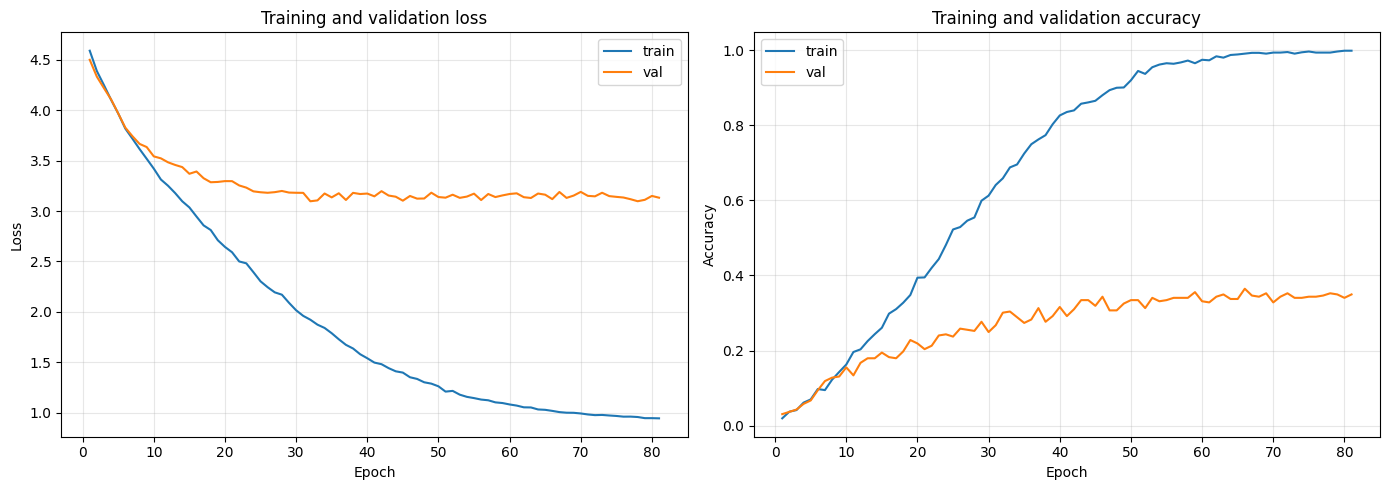

Plot saved to /content/drive/MyDrive/wlasl100_slr/checkpoints/training_curves_bilstm.png


In [20]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], label='train')
ax1.plot(epochs_range, history['val_loss'], label='val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and validation loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='train')
ax2.plot(epochs_range, history['val_acc'], label='val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and validation accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_PROJECT_DIR}/checkpoints/training_curves_bilstm.png', dpi=120)
plt.show()
print(f'Plot saved to {DRIVE_PROJECT_DIR}/checkpoints/training_curves_bilstm.png')

## 7. Evaluation

Top-1 / Top-5 accuracy on the held-out test split, plus a per-class classification report
and confusion matrix.

In [21]:
eval_loader = test_loader if test_loader is not None else val_loader
eval_name = 'test' if test_loader is not None else 'val'
print(f'Evaluating on the {eval_name} split ({len(eval_loader.dataset)} clips)')

model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for xb, yb in eval_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_logits.append(logits.cpu())
        all_labels.append(yb)

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_probs = torch.softmax(all_logits, dim=-1)

top1_preds = all_probs.argmax(dim=-1)
top1_acc = (top1_preds == all_labels).float().mean().item()

top5_preds = all_probs.topk(k=5, dim=-1).indices
top5_acc = (top5_preds == all_labels.unsqueeze(1)).any(dim=1).float().mean().item()

print(f'Top-1 accuracy: {top1_acc:.3f}')
print(f'Top-5 accuracy: {top5_acc:.3f}')

Evaluating on the test split (249 clips)
Top-1 accuracy: 0.353
Top-5 accuracy: 0.683


In [22]:
from sklearn.metrics import classification_report

target_names = [label_map[str(i)] for i in range(len(label_map))]
report = classification_report(
    all_labels.numpy(), top1_preds.numpy(),
    target_names=target_names, zero_division=0,
)
print(report)

with open(f'{DRIVE_PROJECT_DIR}/checkpoints/classification_report_bilstm.txt', 'w') as f:
    f.write(report)

              precision    recall  f1-score   support

        book       0.50      1.00      0.67         4
       drink       1.00      0.25      0.40         4
    computer       0.25      0.20      0.22         5
      before       0.50      0.25      0.33         4
       chair       0.29      0.67      0.40         3
          go       0.50      0.67      0.57         3
     clothes       1.00      0.67      0.80         3
         who       0.00      0.00      0.00         3
       candy       0.33      0.33      0.33         3
      cousin       0.00      0.00      0.00         3
        deaf       0.50      0.33      0.40         3
        fine       0.00      0.00      0.00         2
        help       0.50      0.67      0.57         3
          no       0.20      0.33      0.25         3
        thin       0.00      0.00      0.00         3
        walk       0.33      0.67      0.44         3
        year       1.00      0.33      0.50         3
         yes       0.00    

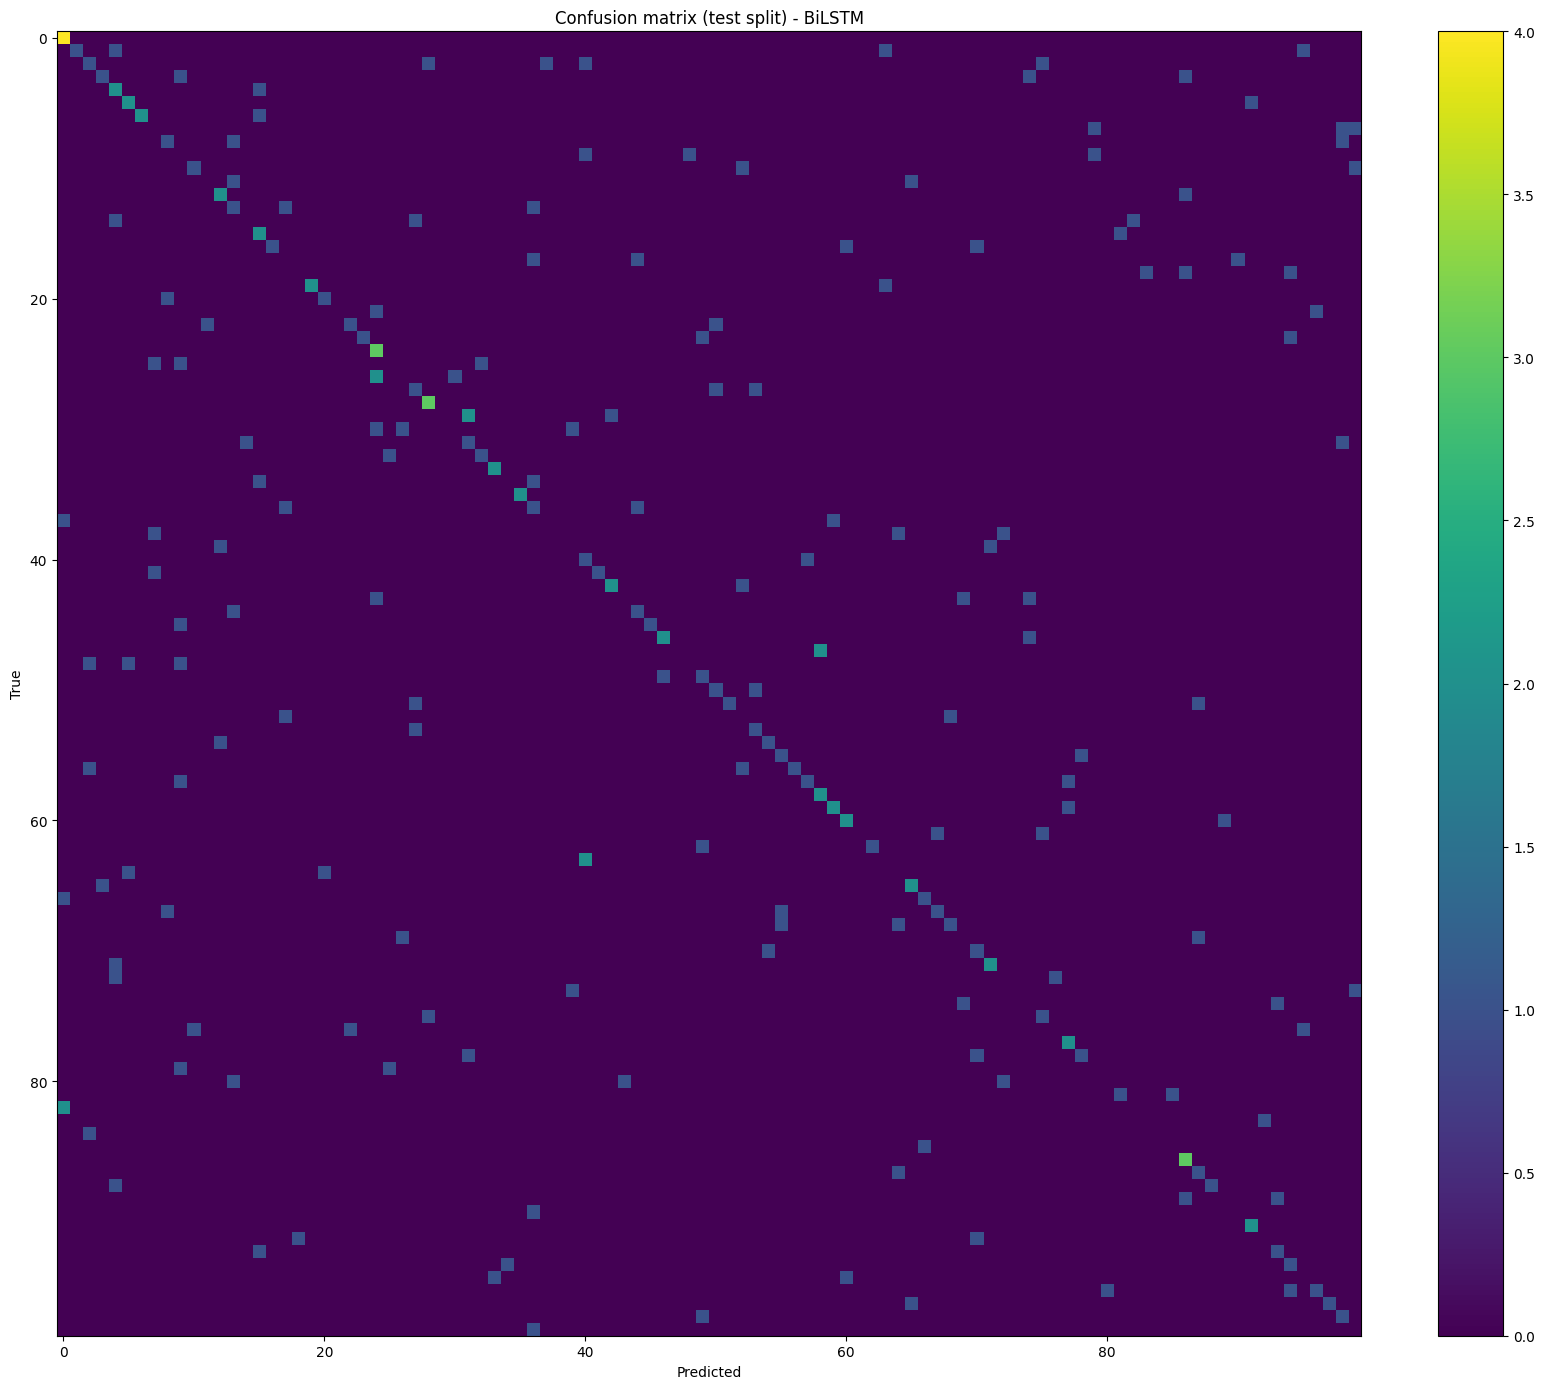

Most-confused (true -> predicted) pairs:
  now                  -> many                  (2 times)
  forget               -> hat                   (2 times)
  city                 -> book                  (2 times)
  thanksgiving         -> woman                 (2 times)
  study                -> dance                 (2 times)
  last                 -> before                (1 times)
  now                  -> what                  (1 times)
  fish                 -> who                   (1 times)
  paper                -> all                   (1 times)
  thin                 -> chair                 (1 times)
  black                -> forget                (1 times)
  but                  -> no                    (1 times)
  bed                  -> mother                (1 times)
  give                 -> go                    (1 times)
  same                 -> but                   (1 times)


In [23]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels.numpy(), top1_preds.numpy())

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap='viridis')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion matrix ({eval_name} split) - BiLSTM')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(f'{DRIVE_PROJECT_DIR}/checkpoints/confusion_matrix_bilstm.png', dpi=120)
plt.show()

# Most-confused class pairs (top 15 off-diagonal counts)
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
flat_idx = np.argsort(cm_off_diag, axis=None)[::-1][:15]
print('Most-confused (true -> predicted) pairs:')
for idx in flat_idx:
    i, j = np.unravel_index(idx, cm_off_diag.shape)
    count = cm_off_diag[i, j]
    if count == 0:
        break
    print(f'  {target_names[i]:<20s} -> {target_names[j]:<20s}  ({int(count)} times)')

## 8. Save artifacts to Drive

The best checkpoint has already been saved to Drive during training (Section 5).
The config file and model source are also saved for reproducibility.

In [24]:
!cp config_bilstm.yaml "{DRIVE_PROJECT_DIR}/checkpoints/"
!cp sign_language_model_bilstm.py "{DRIVE_PROJECT_DIR}/checkpoints/"
print('Artifacts saved to:', f'{DRIVE_PROJECT_DIR}/checkpoints/')
!ls -lh "{DRIVE_PROJECT_DIR}/checkpoints/"

Artifacts saved to: /content/drive/MyDrive/wlasl100_slr/checkpoints/
total 18M
-rw------- 1 root root  11M Jul  7 15:32 best_model_bilstm.pt
-rw------- 1 root root 6.0M Jul  7 05:28 best_model.pt
-rw------- 1 root root 5.5K Jul  7 16:08 classification_report_bilstm.txt
-rw------- 1 root root 5.5K Jul  7 05:31 classification_report.txt
-rw------- 1 root root  741 Jul  7 16:09 config_bilstm.yaml
-rw------- 1 root root 2.8K Jul  7 05:33 config.yaml
-rw------- 1 root root  44K Jul  7 16:09 confusion_matrix_bilstm.png
-rw------- 1 root root  43K Jul  7 05:32 confusion_matrix.png
-rw------- 1 root root 1.7K Jul  7 05:33 label_map.json
-rw------- 1 root root  12K Jul  7 16:09 sign_language_model_bilstm.py
-rw------- 1 root root  27K Jul  7 05:33 sign_language_model.py
-rw------- 1 root root  80K Jul  7 15:44 training_curves_bilstm.png
-rw------- 1 root root  60K Jul  7 05:30 training_curves.png


## 9. Inference sanity check

Loads a sample from the evaluation set and runs inference through `predict_from_features`
to verify the saved checkpoint loads correctly and produces reasonable predictions.

In [25]:
sample_inst = (test_instances if test_instances else val_instances)[0]
print('Ground-truth gloss:', label_map[str(sample_inst['label_index'])])

from sign_language_model_bilstm import SignLanguageRecognizer

recognizer = SignLanguageRecognizer(
    checkpoint_path=CHECKPOINT_PATH,
    models_dir='models',
    create_extractor=False,
)
if not recognizer.ready:
    print('ERROR initializing recognizer:', recognizer.init_error)
else:
    # Load features directly from the cached .npz
    with np.load(f"{FEATURES_DIR}/{sample_inst['video_id']}.npz") as data:
        sample_features = data['features']
    result = recognizer.predict_from_features(sample_features, top_k=5)
    print('Prediction result:')
    for r in result['top_k']:
        print(f'  {r["class"]:<20s} {r["confidence"]:.3f}')
    correct = result['predicted_class'] == label_map[str(sample_inst['label_index'])]
    print(f'Top-1 correct: {correct}')

recognizer.close()

Ground-truth gloss: shirt
Prediction result:
  shirt                0.455
  before               0.148
  dog                  0.145
  thursday             0.079
  go                   0.022
Top-1 correct: True
